# Aggregate population to grid

Aggregate the clipped HRSL raster to the 1 km analysis grid, compute population per grid cell, and save the grid with population attributes for downstream accessibility and burden analysis.

In [1]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.features import geometry_mask

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import (
    CITY_NAME,
    CRS_WGS84,
    FILES,
    ensure_project_dirs,
    savefig,
    print_config_summary,
)

ensure_project_dirs()
print_config_summary()

===== CONFIG =====
City: Nairobi
BBOX: {'lon_min': 36.6, 'lat_min': -1.5, 'lon_max': 37.1, 'lat_max': -1.1}
Grid Size: 1000 m
Top-K Hospitals: 3
Alpha: 1.5
Beta: 1.0
HRSL Path: /Users/suvo/Projects/urban-healthcare/data/raw/population/hrsl_kenya.tif


In [2]:
grid = gpd.read_parquet(FILES["grid"])
grid.head()

,grid_id,geometry,cell_area_m2,cell_area_km2
0,g_00000,"POLYGON ((4075293.363 -165998.314, 4075293.363...",1000000.0,1.0
1,g_00001,"POLYGON ((4075293.363 -164998.314, 4075293.363...",1000000.0,1.0
2,g_00002,"POLYGON ((4075293.363 -163998.314, 4075293.363...",1000000.0,1.0
3,g_00003,"POLYGON ((4075293.363 -162998.314, 4075293.363...",1000000.0,1.0
4,g_00004,"POLYGON ((4075293.363 -161998.314, 4075293.363...",1000000.0,1.0


In [3]:
with rasterio.open(FILES["hrsl_clipped"]) as src:
    hrsl_data = src.read(1)
    hrsl_transform = src.transform
    hrsl_crs = src.crs
    hrsl_nodata = src.nodata
    hrsl_bounds = src.bounds

print("HRSL CRS:", hrsl_crs)
print("HRSL bounds:", hrsl_bounds)
print("HRSL nodata:", hrsl_nodata)
print("HRSL shape:", hrsl_data.shape)

HRSL CRS: EPSG:4326
HRSL bounds: BoundingBox(left=36.59986111128532, bottom=-1.5001388889474772, right=37.1001388890635, top=-1.0998611111693775)
HRSL nodata: nan
HRSL shape: (1441, 1801)


In [4]:
grid_hrsl = grid.to_crs(hrsl_crs)
print("Grid CRS:", grid_hrsl.crs)

Grid CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


In [5]:
if hrsl_nodata is not None:
    hrsl_data = np.where(hrsl_data == hrsl_nodata, 0, hrsl_data)

hrsl_data = np.where(np.isnan(hrsl_data), 0, hrsl_data)

In [6]:
population_values = []

for geom in grid_hrsl.geometry:
    mask_array = geometry_mask(
        [geom],
        transform=hrsl_transform,
        invert=True,
        out_shape=hrsl_data.shape
    )
    pop_value = hrsl_data[mask_array].sum()
    population_values.append(float(pop_value))

grid["population"] = population_values

In [7]:
grid["population_density_km2"] = grid["population"] / grid["cell_area_km2"]

print("Total population in clipped grid:", grid["population"].sum())
print("Nonzero cells:", (grid["population"] > 0).sum())
grid[["grid_id", "population", "population_density_km2"]].head()

Total population in clipped grid: 7530096.4525379995
Nonzero cells: 2328


,grid_id,population,population_density_km2
0,g_00000,0.000000,0.000000
1,g_00001,13.913320,13.913320
2,g_00002,13.913320,13.913320
3,g_00003,16.695984,16.695984
4,g_00004,91.827912,91.827912


Saved: /Users/suvo/Projects/urban-healthcare/outputs/figures/03_grid_population.png


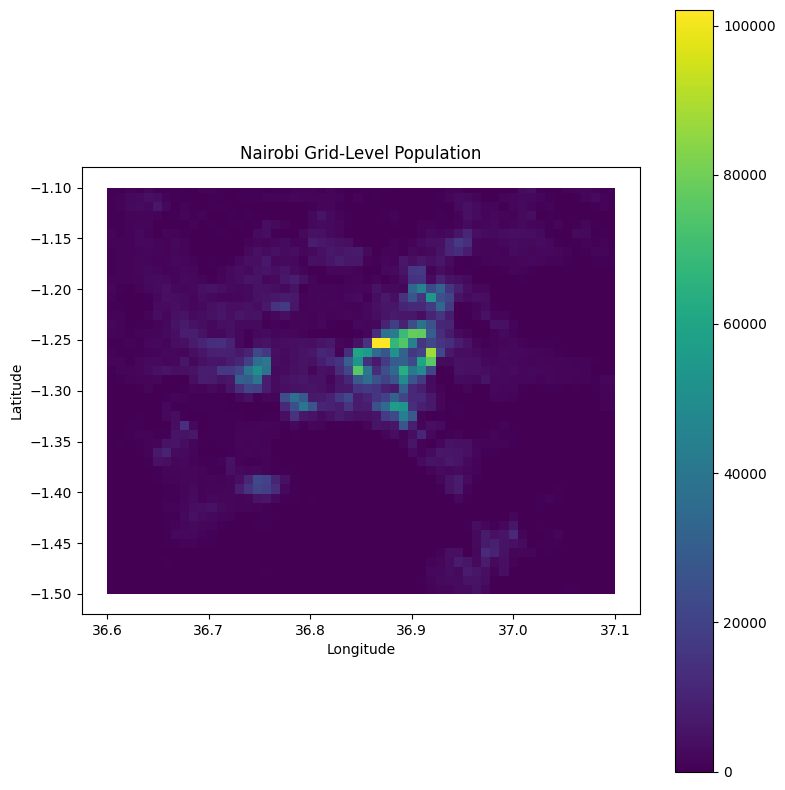

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))
grid_wgs84 = grid.to_crs(CRS_WGS84)

grid_wgs84.plot(
    column="population",
    ax=ax,
    legend=True,
    cmap="viridis",
    linewidth=0
)

ax.set_title(f"{CITY_NAME} Grid-Level Population")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()

savefig(fig, "03_grid_population.png")
plt.show()

Saved: /Users/suvo/Projects/urban-healthcare/outputs/figures/03_population_log.png


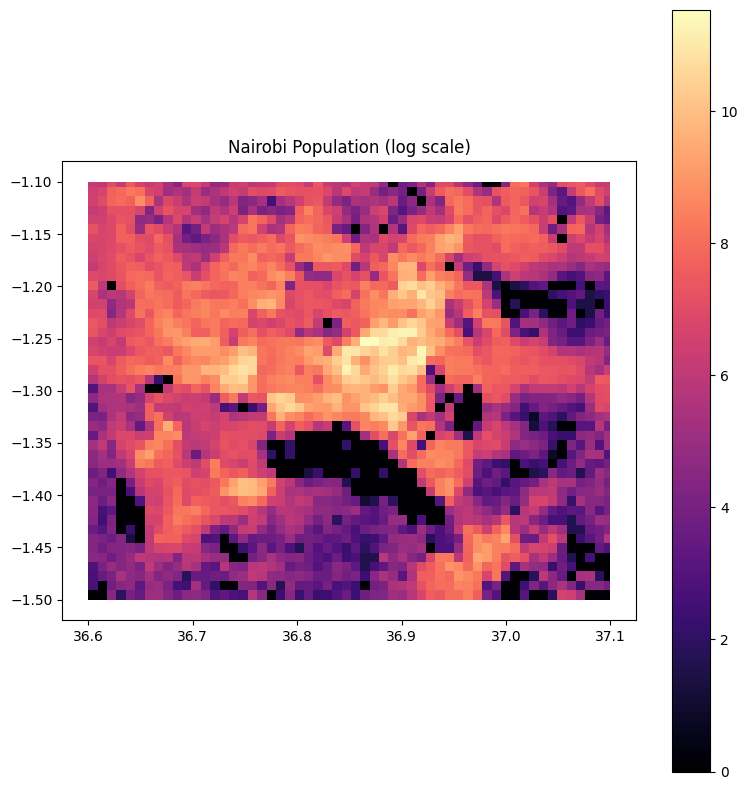

In [13]:
import numpy as np

grid_wgs84["log_population"] = np.log1p(grid_wgs84["population"])

fig, ax = plt.subplots(figsize=(8, 8))

grid_wgs84.plot(
    column="log_population",
    ax=ax,
    legend=True,
    cmap="magma",
    linewidth=0
)

ax.set_title(f"{CITY_NAME} Population (log scale)")
plt.tight_layout()

savefig(fig, "03_population_log.png")
plt.show()

In [10]:
grid.to_parquet(FILES["grid_population"], index=False)
print("Saved grid population to:", FILES["grid_population"])

Saved grid population to: /Users/suvo/Projects/urban-healthcare/data/processed/grid_population.parquet
